In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.shape
df.info()
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [4]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [5]:
df = df.dropna()


In [6]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [8]:
df[' Date'] = pd.to_datetime(df[' Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Region                                    740 non-null    object        
 1    Date                                     740 non-null    datetime64[ns]
 2    Frequency                                740 non-null    object        
 3    Estimated Unemployment Rate (%)          740 non-null    float64       
 4    Estimated Employed                       740 non-null    float64       
 5    Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                      740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


/tmp/ipykernel_997/2464846234.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[' Date'] = pd.to_datetime(df[' Date'])


In [9]:
df[' Month'] = df[' Date'].dt.month_name()

In [12]:
region_avg = df.groupby("Region")[" Estimated Unemployment Rate (%)"].mean()
region_avg

,Estimated Unemployment Rate (%)
Region,
Andhra Pradesh,7.477143
Assam,6.428077
Bihar,18.918214
Chandigarh,15.991667
Chhattisgarh,9.240357
Delhi,16.495357
Goa,9.274167
Gujarat,6.663929
Haryana,26.283214


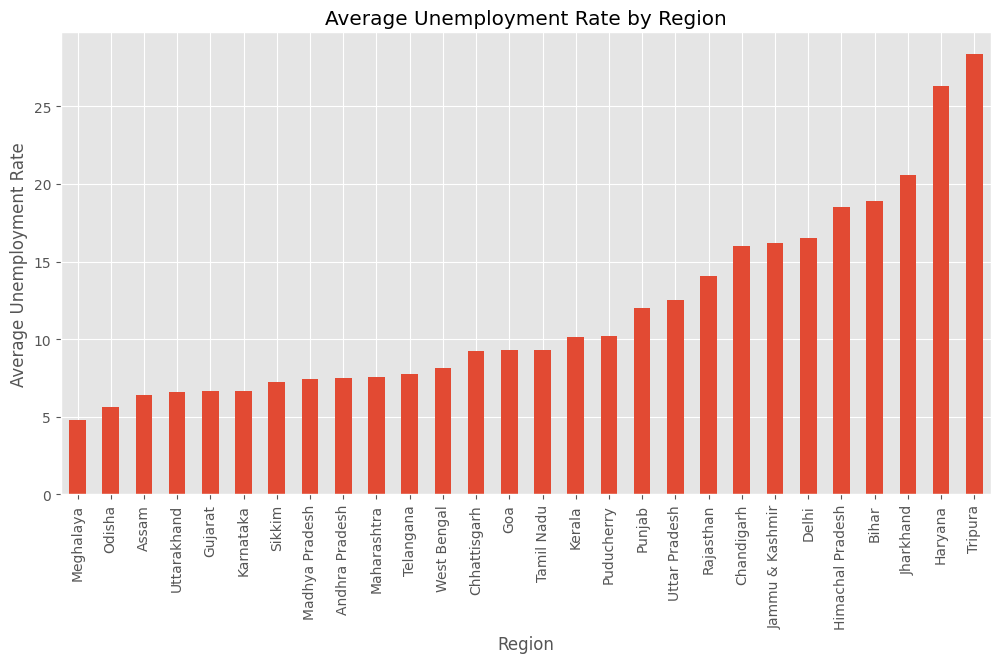

In [13]:
plt.figure(figsize=(12,6))

region_avg.sort_values().plot(kind="bar")

plt.title("Average Unemployment Rate by Region")

plt.ylabel("Average Unemployment Rate")

plt.xticks(rotation=90)

plt.show()

Some regions experience higher unemployment than others. The variation indicates differences in economic development and employment opportunities.

In [16]:
# Month wise trend
month_avg = df.groupby(" Month")[" Estimated Unemployment Rate (%)"].mean()

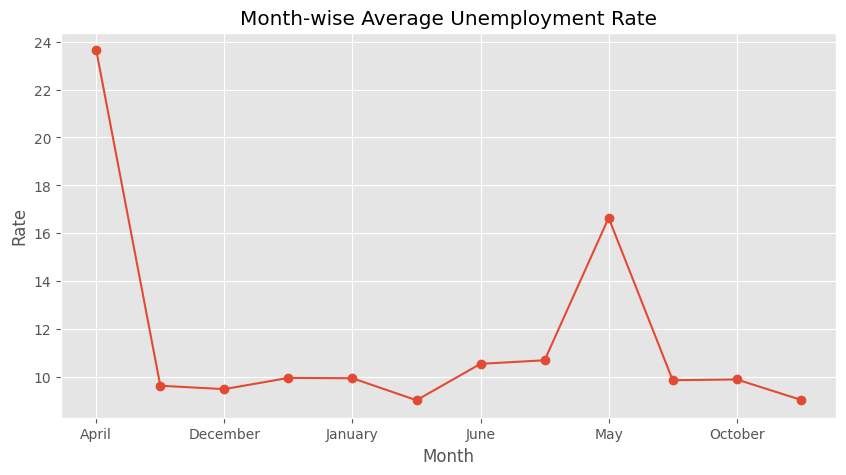

In [17]:
plt.figure(figsize=(10,5))

month_avg.plot(marker='o')

plt.title("Month-wise Average Unemployment Rate")

plt.xlabel("Month")

plt.ylabel("Rate")

plt.show()

Unemployment varies throughout the year.

In [32]:
# unemployment rate over time for 4 major states
states = ['Karnataka','Maharashtra','Tamil Nadu','Delhi']

state_df = df[df['Region'].isin(states)]

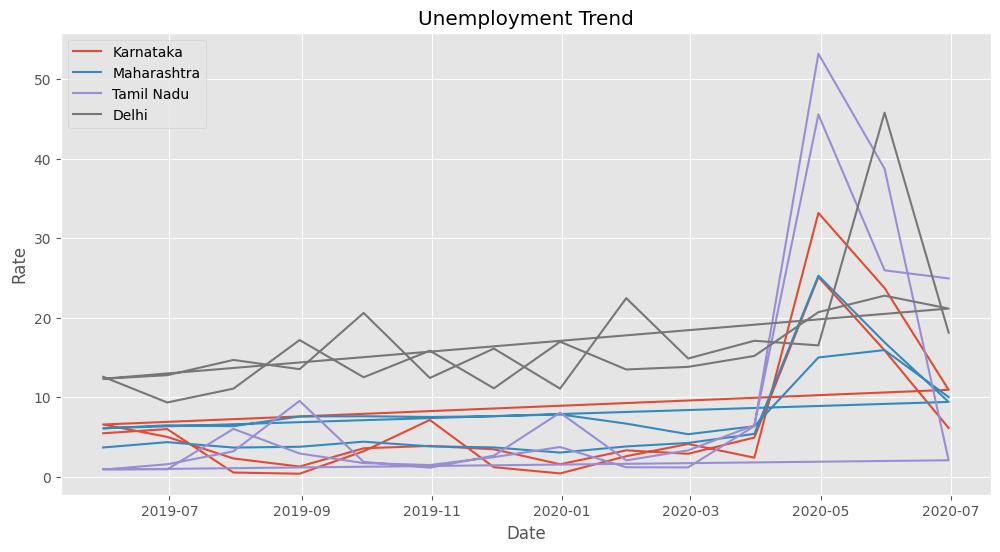

In [33]:
plt.figure(figsize=(12,6))

for state in states:

    temp = state_df[state_df['Region']==state]

    plt.plot(temp[' Date'],
             temp[' Estimated Unemployment Rate (%)'],
             label=state)

plt.legend()

plt.title("Unemployment Trend")

plt.xlabel("Date")

plt.ylabel("Rate")

plt.show()

All 4 states experienced a sharp increase in unemployment during the COVID-19 period.

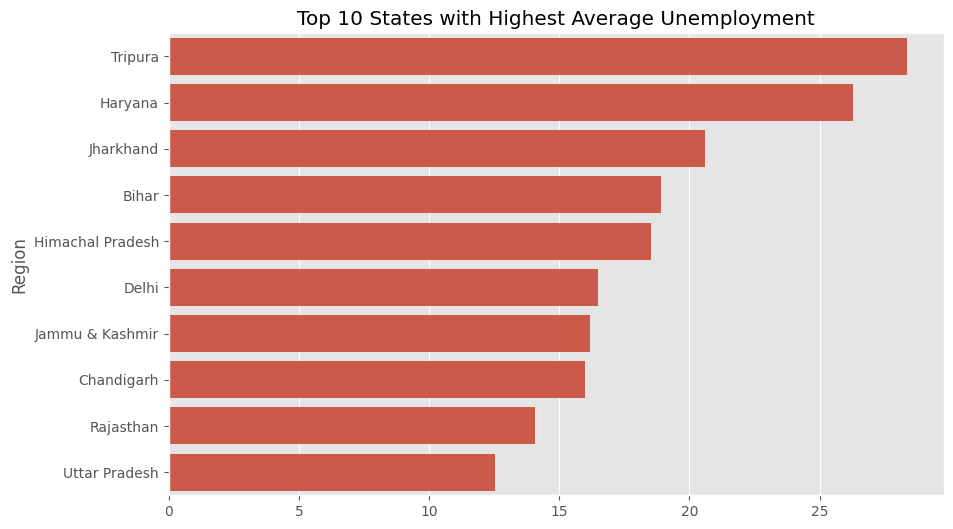

In [23]:
#top 10 states with highest average unemployment
top10 = df.groupby("Region")[" Estimated Unemployment Rate (%)"]\
.mean()\
.sort_values(ascending=False)\
.head(10)
plt.figure(figsize=(10,6))

sns.barplot(x=top10.values,
            y=top10.index)

plt.title("Top 10 States with Highest Average Unemployment")

plt.show()

The states shown have the highest average unemployment rates during the observation period.

In [26]:
# Correlation Heatmap
corr = df[[
    ' Estimated Unemployment Rate (%)',
    ' Estimated Employed',
    ' Estimated Labour Participation Rate (%)'
]].corr()

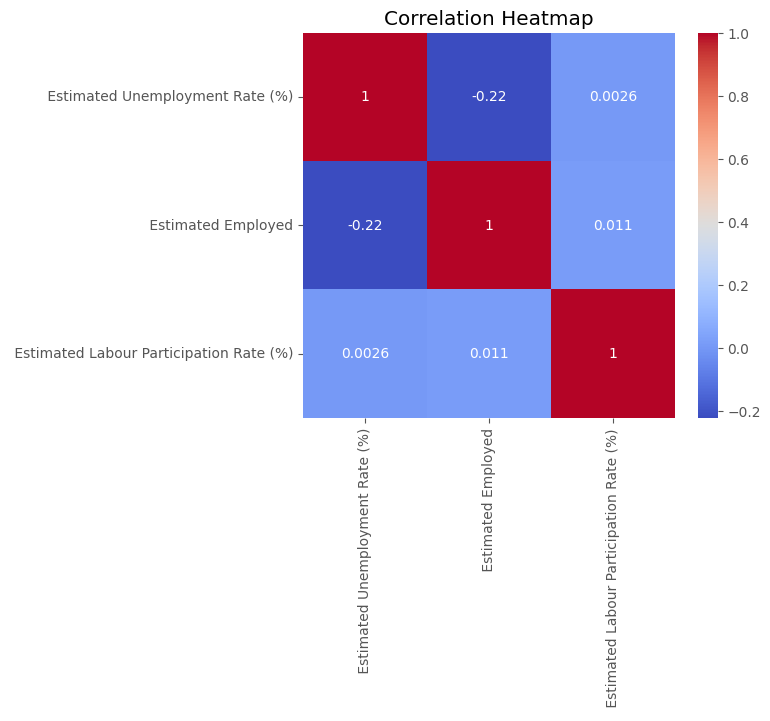

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [29]:
# Pre-Covid vs Post-Covid
pre = df[df[' Date'] < '2020-03-01']

post = df[df[' Date'] >= '2020-03-01']
pre_mean = pre[' Estimated Unemployment Rate (%)'].mean()

post_mean = post[' Estimated Unemployment Rate (%)'].mean()

print(pre_mean)

print(post_mean)

9.509533582089553
17.774362745098042


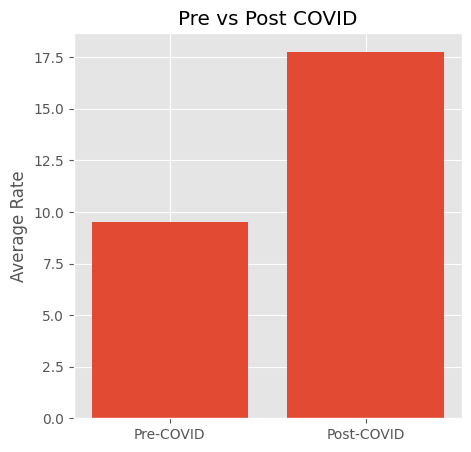

In [30]:
plt.figure(figsize=(5,5))

plt.bar(['Pre-COVID','Post-COVID'],
        [pre_mean,post_mean])

plt.ylabel("Average Rate")

plt.title("Pre vs Post COVID")

plt.show()

The average employment rate increased noticeably after COVID-19.